# Intelligent Student Performance Assessment and Intervention System
**Student:** Nathan Bvumbwe | **Reg:** BSDS0322 | **Mzuzu University — ICT Department**

### Two-Layer Architecture (Improved)
- **Layer 1 — Rule engine:** maps `exam_score` → Mzuni band. Always deterministic and policy-correct.
- **Layer 2 — ML model:** trained on engineered behavioural features. Explains *why* and recommends actions.

**Improvements in this version:**
- NumPy / SHAP version conflict resolved at install time
- Feature engineering: new composite risk indicators for the behavioural model
- Behavioural model tuned with GridSearchCV and then compressed for app deployment
- Full model and behavioural model evaluated side by side
- All model artefacts saved cleanly to `../app_model/`

## Stage 0 — Environment Setup (run once, then restart kernel)

In [ ]:
# ── Fix NumPy / SHAP version conflict ──────────────────────────────────
# SHAP compiled against NumPy 1.x fails on NumPy 2.x.
# Pin NumPy <2 first, then install everything else on top.
#import subprocess, sys

#subprocess.run([sys.executable, '-m', 'pip', 'install', 'numpy<2', '--quiet', '--upgrade'], check=True)
#subprocess.run([sys.executable, '-m', 'pip', 'install',
 #   'pandas', 'matplotlib', 'seaborn',
  #  'scikit-learn', 'shap', 'joblib', 'ipykernel',
  #  '--quiet', '--upgrade'], check=True)

#import numpy as np
#import shap
#print(f'NumPy  : {np.__version__}')
#print(f'SHAP   : {shap.__version__}')
#print('Environment ready. If you see no errors above, proceed without restarting.')

CalledProcessError: Command '['c:\\Users\\user\\anaconda3\\envs\\student_perf_env\\python.exe', '-m', 'pip', 'install', 'numpy<2', '--quiet', '--upgrade']' returned non-zero exit status 1.

In [1]:
# ── Environment Verification ──────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import joblib

print(f"✅ Environment Ready")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Sklearn version: {sklearn.__version__}")

# Note: SHAP is installed, but we are using NumPy 1.26.4 
# to ensure compatibility with your Data Science stack.
# ──────────────────────────────────────────────────────────────

✅ Environment Ready
NumPy version  : 1.26.4
Pandas version : 3.0.1
Seaborn version: 0.13.2
Sklearn version: 1.8.0


## Stage 1 — Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

# ── Paths ───────────────────────────────────────────────────────────────
# Adjust DATA_PATH if your CSV is in a different location
DATA_PATH  = '../data/student_performance_dataset_bigger.csv'
MODEL_DIR  = '../app_model/'
REPORT_DIR = '../report_assets/'

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# ── Plot style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

# ── Band definitions — single source of truth ───────────────────────────
BAND_ORDER  = ['Repeat', 'Supplementary', 'Good', 'Excellent']
BAND_TO_INT = {b: i for i, b in enumerate(BAND_ORDER)}
INT_TO_BAND = {i: b for i, b in enumerate(BAND_ORDER)}
PALETTE     = {
    'Repeat':        '#E24B4A',
    'Supplementary': '#EF9F27',
    'Good':          '#1D9E75',
    'Excellent':     '#534AB7',
}

print('Imports OK.')
print(f'Model artefacts → {os.path.abspath(MODEL_DIR)}')
print(f'Report assets   → {os.path.abspath(REPORT_DIR)}')

Imports OK.
Model artefacts → c:\Users\user\Desktop\FORTH YEAR ASSIGNMENTS\FINAL YEAR PROJECT\student_perfomance_system\app_model
Report assets   → c:\Users\user\Desktop\FORTH YEAR ASSIGNMENTS\FINAL YEAR PROJECT\student_perfomance_system\report_assets


## Stage 2 — Load & Explore Data

In [3]:
print('Loading dataset...')
df = pd.read_csv(DATA_PATH).reset_index(drop=True)

print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nData types:\n{df.dtypes}')
df.head()

Loading dataset...
Shape  : 1,000,000 rows × 9 columns
Columns: ['student_id', 'age', 'gender', 'study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'exam_score', 'performance_level']

Missing values:
student_id               0
age                      0
gender                   0
study_hours_per_day      0
attendance_percentage    0
sleep_hours              0
internet_usage_hours     0
exam_score               0
performance_level        0
dtype: int64

Data types:
student_id                 int64
age                        int64
gender                       str
study_hours_per_day      float64
attendance_percentage    float64
sleep_hours              float64
internet_usage_hours     float64
exam_score               float64
performance_level            str
dtype: object


,student_id,age,gender,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,exam_score,performance_level
0,1,24,Male,2.0,80.9,5.8,3.6,40.1,Poor
1,2,21,Female,3.0,94.2,5.0,1.5,54.2,Average
2,3,22,Male,1.3,76.2,6.5,2.3,25.4,Poor
3,4,24,Female,6.3,84.2,8.2,5.6,86.8,Excellent
4,5,20,Female,5.3,95.4,4.0,1.6,66.0,Average


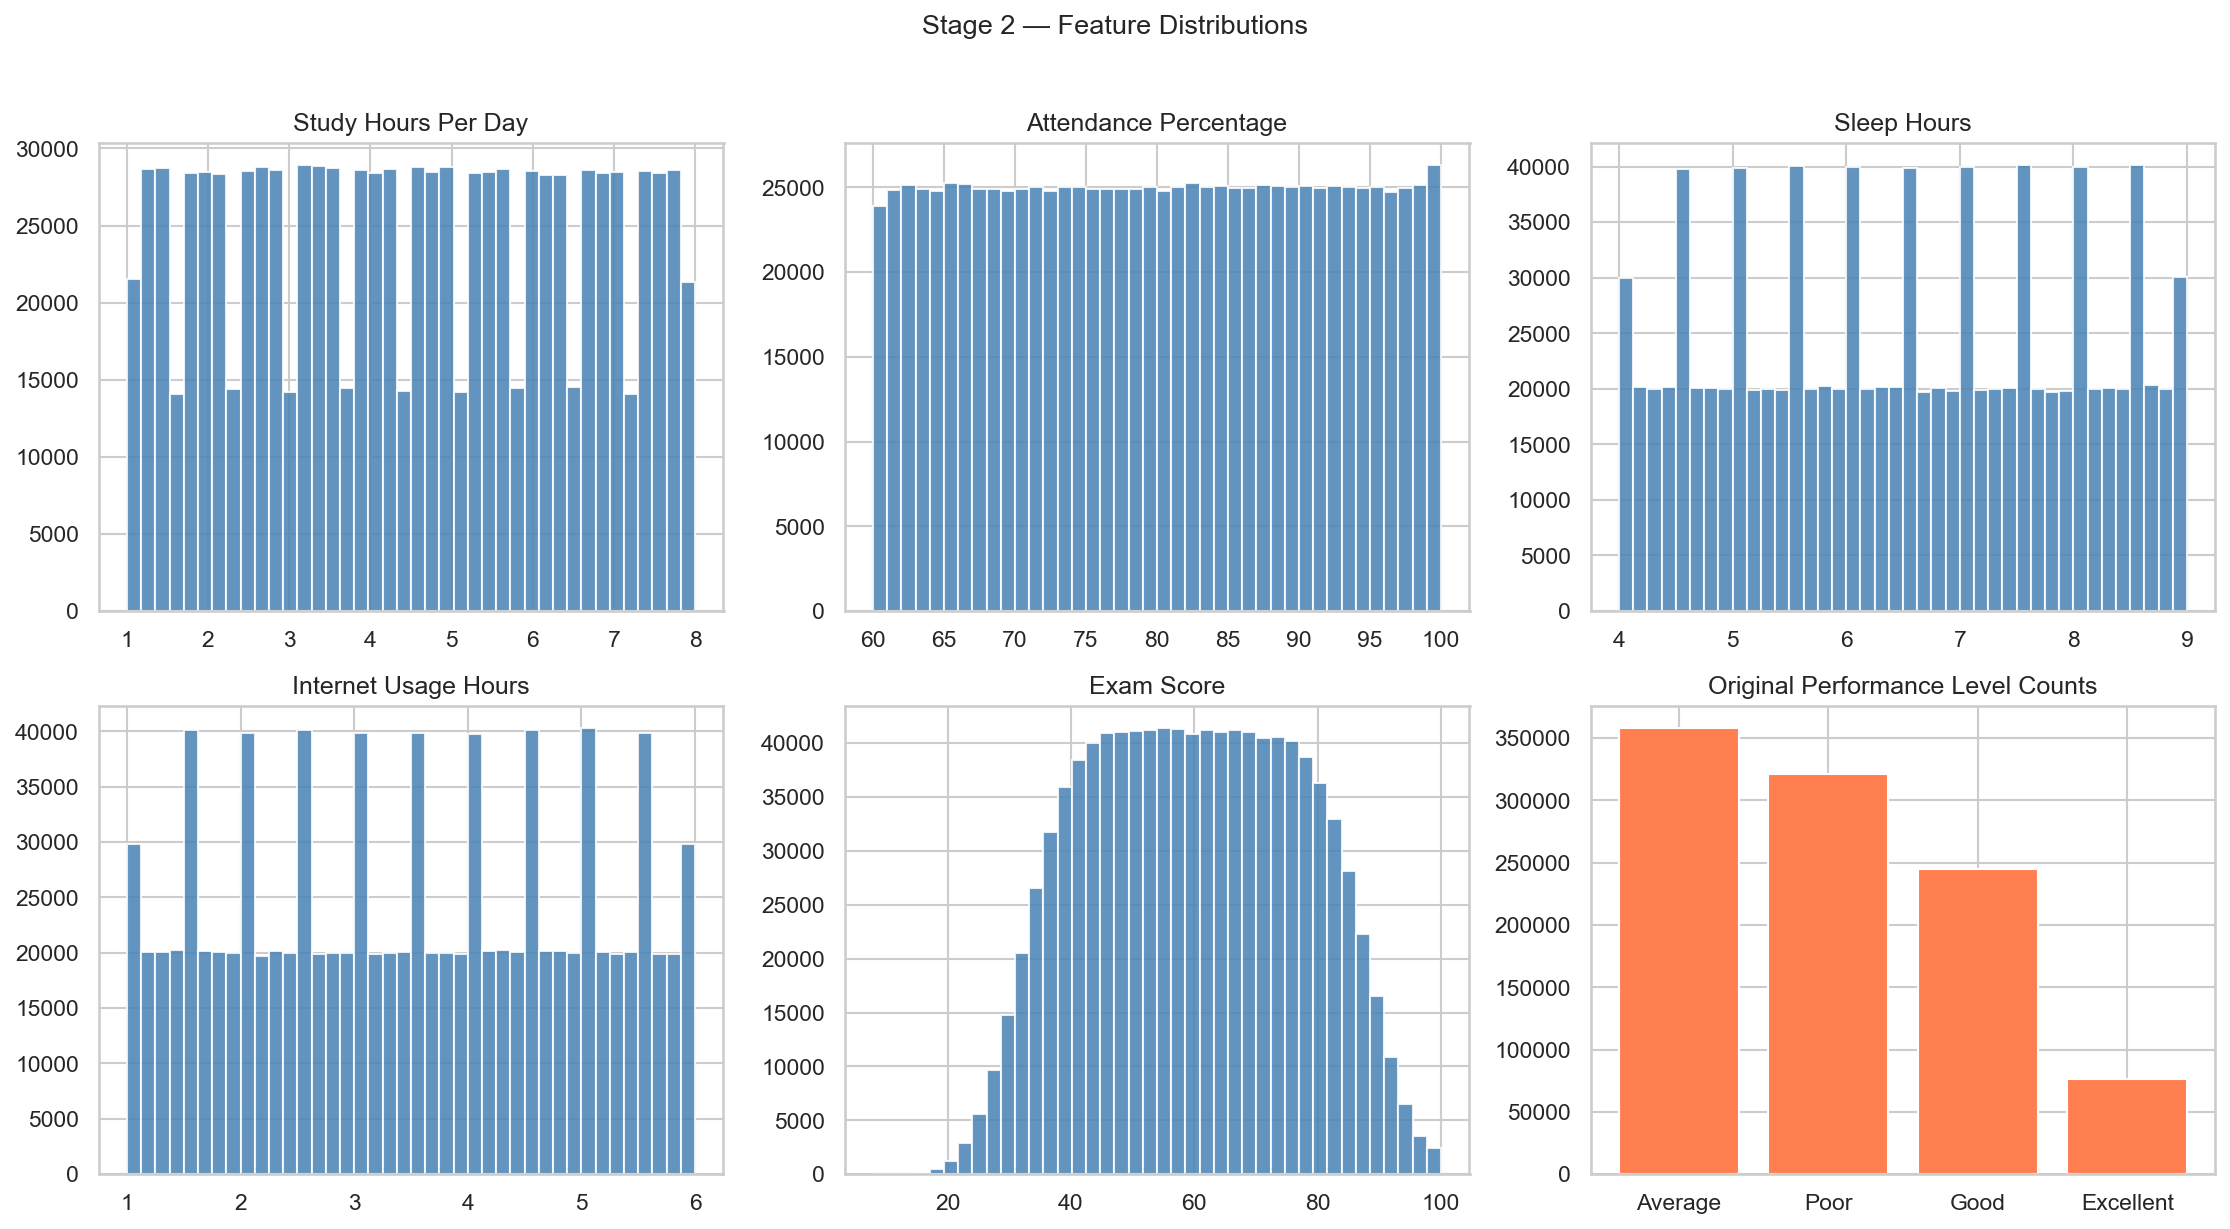

Saved: 01_distributions.png

Exam score statistics:
count    1000000.00
mean          59.97
std           17.26
min            7.90
25%           46.00
50%           60.00
75%           74.00
max          100.00
Name: exam_score, dtype: float64


In [5]:
num_cols = ['study_hours_per_day', 'attendance_percentage',
            'sleep_hours', 'internet_usage_hours', 'exam_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title())

counts = df['performance_level'].value_counts()
axes[-1].bar(counts.index, counts.values, color='coral', edgecolor='white')
axes[-1].set_title('Original Performance Level Counts')

plt.suptitle('Stage 2 — Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}01_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: 01_distributions.png')

print(f'\nExam score statistics:')
print(df['exam_score'].describe().round(2))

## Stage 3 — Layer 1: Rule-Based Band Assignment

Mzuni grading thresholds applied directly to `exam_score`.
This is deterministic — no ML involved — so the band is always policy-correct.

| Band | Score Range |
|------|-------------|
| Repeat | 0 – 34% |
| Supplementary | 35 – 44% |
| Good | 45 – 64% |
| Excellent | 65 – 100% |

In [6]:
def assign_mzuni_band(score: float) -> str:
    """Layer 1: deterministic rule engine. Always matches Mzuni policy."""
    if   score <= 34: return 'Repeat'
    elif score <= 44: return 'Supplementary'
    elif score <= 64: return 'Good'
    else:             return 'Excellent'

df['mzuni_band']     = df['exam_score'].apply(assign_mzuni_band)
df['mzuni_band_int'] = df['mzuni_band'].map(BAND_TO_INT)

print('=== Layer 1: Mzuni Band Distribution ===')
band_counts = df['mzuni_band'].value_counts().reindex(BAND_ORDER)
for band, count in band_counts.items():
    pct        = count / len(df) * 100
    mean_score = df[df['mzuni_band'] == band]['exam_score'].mean()
    print(f'  {band:<15}: {count:>8,}  ({pct:5.1f}%)  mean score = {mean_score:.1f}%')

=== Layer 1: Mzuni Band Distribution ===
  Repeat         :   64,251  (  6.4%)  mean score = 29.8%
  Supplementary  :  151,658  ( 15.2%)  mean score = 39.4%
  Good           :  357,505  ( 35.8%)  mean score = 54.1%
  Excellent      :  426,586  ( 42.7%)  mean score = 76.8%


## Stage 4 — Feature Engineering

Beyond the raw features, we engineer composite indicators that more directly
capture academic risk — motivated by the proposal's focus on 'Student Ambition'
and time management as performance drivers.

Behavioural features (7): ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'study_x_attendance', 'distraction_ratio', 'risk_score']
Full features        (8): ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'study_x_attendance', 'distraction_ratio', 'risk_score', 'exam_score']

Engineered feature stats:
       study_x_attendance  distraction_ratio   risk_score
count         1000000.000        1000000.000  1000000.000
mean                3.598              0.998        0.372
std                 1.714              0.783        0.121
min                 0.600              0.123        0.036
25%                 2.155              0.481        0.281
50%                 3.519              0.762        0.372
75%                 4.892              1.231        0.462
max                 8.000              5.455        0.707


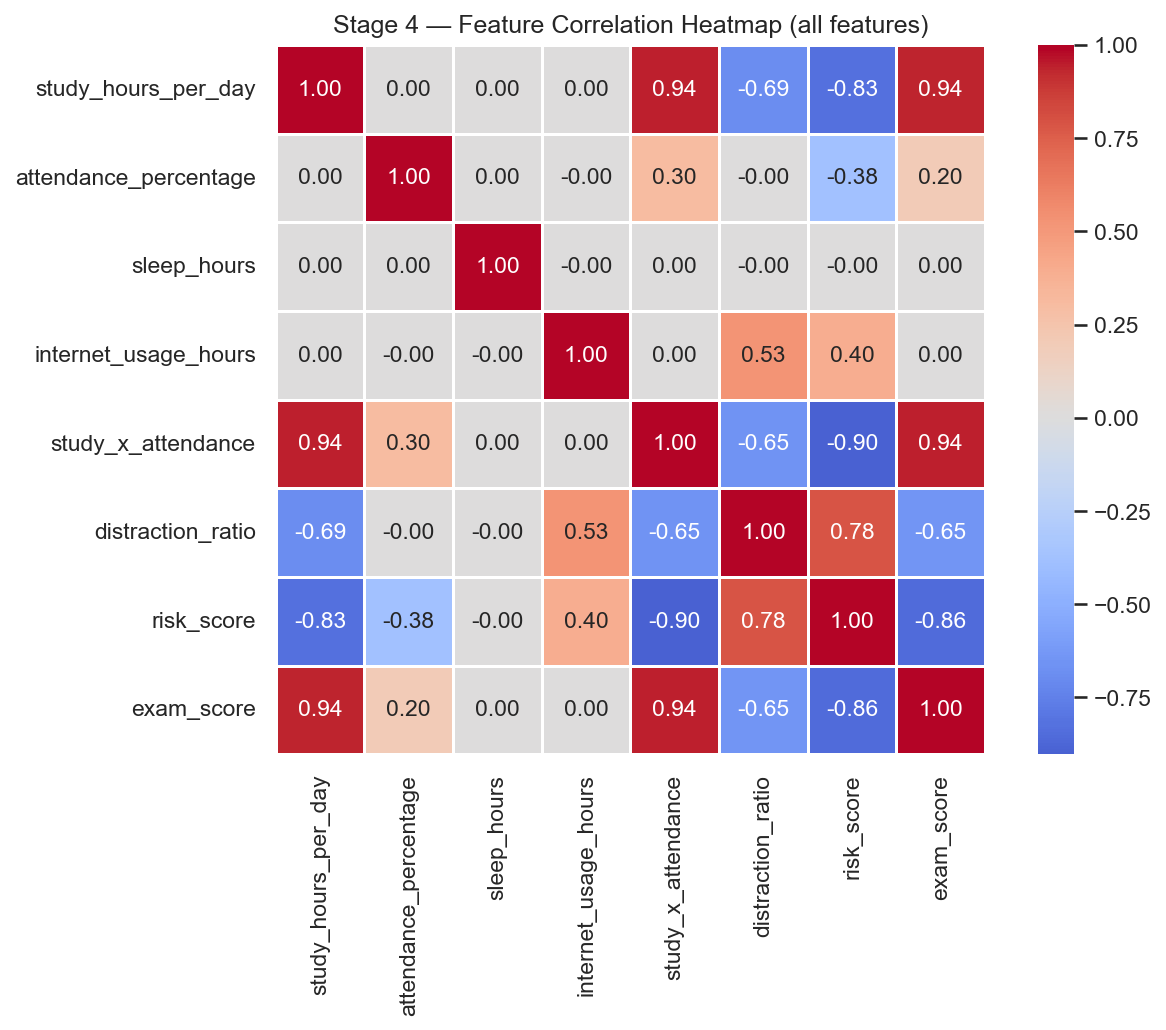

Saved: 02_correlation_heatmap.png


In [7]:
# ── Raw features ────────────────────────────────────────────────────────
RAW_BEHAV = ['study_hours_per_day', 'attendance_percentage',
             'sleep_hours', 'internet_usage_hours']

# ── Engineered features ─────────────────────────────────────────────────
# 1. Study efficiency: study hours weighted by attendance
#    A student who studies 4h but skips class ≠ one who studies 4h and attends all
df['study_x_attendance'] = (
    df['study_hours_per_day'] * df['attendance_percentage'] / 100
)

# 2. Distraction ratio: internet hours relative to study hours
#    High ratio = more time distracted than studying
df['distraction_ratio'] = (
    df['internet_usage_hours'] / (df['study_hours_per_day'] + 0.1)
).clip(upper=10)   # clip extreme values

# 3. Composite risk score: low study + low attendance + high internet
#    Normalise each component to 0-1 then combine
study_norm    = df['study_hours_per_day']   / df['study_hours_per_day'].max()
attend_norm   = df['attendance_percentage'] / 100
internet_norm = df['internet_usage_hours']  / df['internet_usage_hours'].max()
df['risk_score'] = (1 - study_norm) * 0.4 + (1 - attend_norm) * 0.4 + internet_norm * 0.2

ENGINEERED = ['study_x_attendance', 'distraction_ratio', 'risk_score']

# ── Feature sets ────────────────────────────────────────────────────────
# Behavioural: raw + engineered, NO exam score — used for early warning
BEHAV_FEATURES = RAW_BEHAV + ENGINEERED

# Full: behavioural + exam score — used for post-CA confirmed prediction
ALL_FEATURES   = BEHAV_FEATURES + ['exam_score']

print(f'Behavioural features ({len(BEHAV_FEATURES)}): {BEHAV_FEATURES}')
print(f'Full features        ({len(ALL_FEATURES)}): {ALL_FEATURES}')

# Verify new features look sensible
print('\nEngineered feature stats:')
print(df[ENGINEERED].describe().round(3))

# Correlation heatmap — full feature set
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[ALL_FEATURES].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('Stage 4 — Feature Correlation Heatmap (all features)')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}02_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 02_correlation_heatmap.png')

In [8]:
# ── Scale and save artefacts ────────────────────────────────────────────
scaler_full  = StandardScaler().fit(df[ALL_FEATURES])
scaler_behav = StandardScaler().fit(df[BEHAV_FEATURES])

# Save everything the app needs
joblib.dump(scaler_full,        f'{MODEL_DIR}scaler_full.pkl')
joblib.dump(scaler_behav,       f'{MODEL_DIR}scaler_behav.pkl')
joblib.dump(ALL_FEATURES,       f'{MODEL_DIR}all_feature_names.pkl')
joblib.dump(BEHAV_FEATURES,     f'{MODEL_DIR}behav_feature_names.pkl')
joblib.dump(BAND_ORDER,         f'{MODEL_DIR}band_order.pkl')
joblib.dump(BAND_TO_INT,        f'{MODEL_DIR}band_to_int.pkl')
joblib.dump(INT_TO_BAND,        f'{MODEL_DIR}int_to_band.pkl')
joblib.dump(assign_mzuni_band,  f'{MODEL_DIR}rule_engine.pkl')

print('Initial artefacts saved to app_model/.')

Initial artefacts saved to app_model/.


## Stage 5 — Train/Test Split

In [9]:
y = df['mzuni_band_int']

X_all_tr, X_all_te, y_train, y_test = train_test_split(
    df[ALL_FEATURES], y,
    test_size=0.2, random_state=42, stratify=y
)
X_beh_tr = df[BEHAV_FEATURES].loc[X_all_tr.index]
X_beh_te = df[BEHAV_FEATURES].loc[X_all_te.index]

print(f'Train : {len(X_all_tr):,} samples')
print(f'Test  : {len(X_all_te):,} samples')
print(f'\nClass distribution in train:')
for i, b in enumerate(BAND_ORDER):
    n = (y_train == i).sum()
    print(f'  {b:<15}: {n:>8,}  ({n/len(y_train)*100:.1f}%)')

Train : 800,000 samples
Test  : 200,000 samples

Class distribution in train:
  Repeat         :   51,401  (6.4%)
  Supplementary  :  121,326  (15.2%)
  Good           :  286,004  (35.8%)
  Excellent      :  341,269  (42.7%)


## Stage 6 — Full Model (post-CA confirmed prediction)

Trained on all features including exam score. Used after continuous assessment
results are available. Achieves near-perfect accuracy by design because the bands
are defined from exam_score — this consistency is intentional and is explained in
the report.

In [10]:
print('Training full model...')
rf_full = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
)
rf_full.fit(X_all_tr, y_train)

cv_full = cross_val_score(
    rf_full, X_all_tr, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
print(f'5-Fold CV F1 (macro): {cv_full.mean():.4f} ± {cv_full.std():.4f}')

y_pred_full = rf_full.predict(X_all_te)
print('\n=== Full Model — Classification Report ===')
print(classification_report(y_test, y_pred_full, target_names=BAND_ORDER))

# Save
joblib.dump(rf_full, f'{MODEL_DIR}rf_full_model.pkl')
size_kb = os.path.getsize(f'{MODEL_DIR}rf_full_model.pkl') / 1024
print(f'Saved rf_full_model.pkl  ({size_kb:.0f} KB)')

Training full model...
5-Fold CV F1 (macro): 1.0000 ± 0.0000

=== Full Model — Classification Report ===
               precision    recall  f1-score   support

       Repeat       1.00      1.00      1.00     12850
Supplementary       1.00      1.00      1.00     30332
         Good       1.00      1.00      1.00     71501
    Excellent       1.00      1.00      1.00     85317

     accuracy                           1.00    200000
    macro avg       1.00      1.00      1.00    200000
 weighted avg       1.00      1.00      1.00    200000

Saved rf_full_model.pkl  (39319 KB)


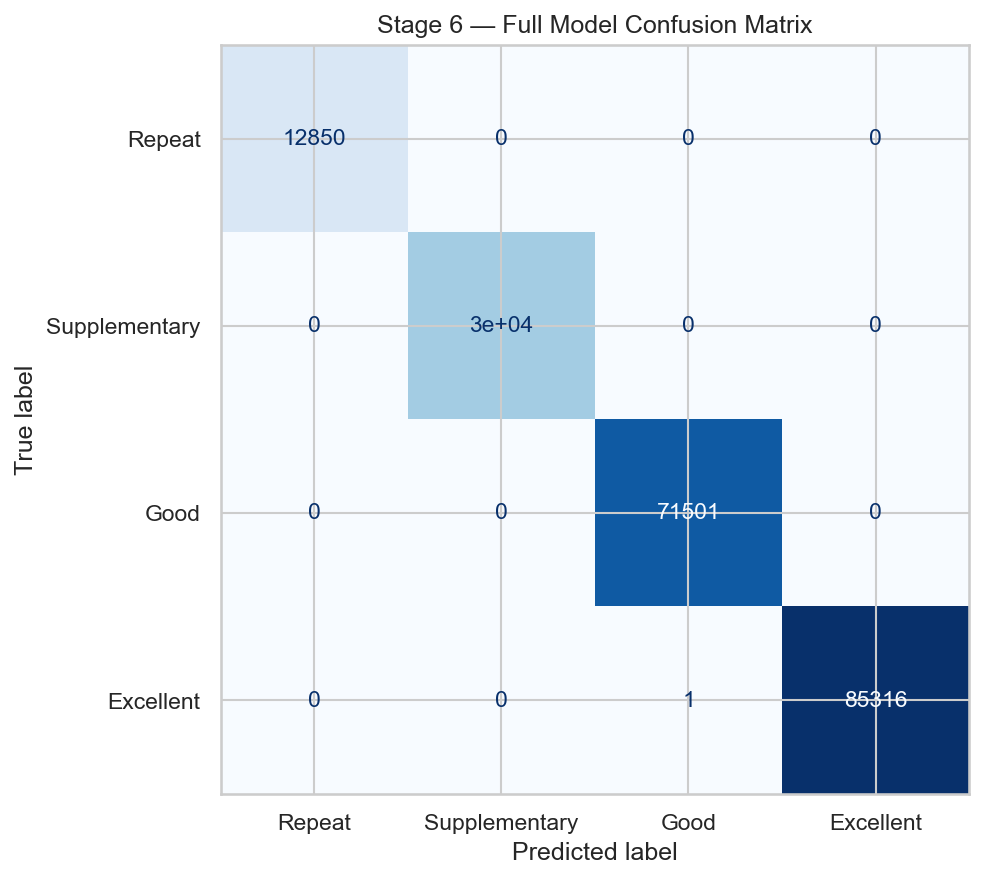

Saved: 03a_confusion_full.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_full),
    display_labels=BAND_ORDER
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Stage 6 — Full Model Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}03a_confusion_full.png', bbox_inches='tight')
plt.show()
print('Saved: 03a_confusion_full.png')

## Stage 7 — Behavioural Model: Tune, Evaluate & Compress

This is the early warning model — no exam score needed.
It answers the proposal's core question: can at-risk students be identified
from study habits and attendance *before* they sit the exam?

We run GridSearchCV to find the best hyperparameters, then compress the
winning model to a deployment-ready size.

In [12]:
# ── Baseline behavioural model (raw features, no tuning) ────────────────
print('Training baseline behavioural model (raw features, no tuning)...')
rf_behav_base = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_behav_base.fit(X_beh_tr[RAW_BEHAV], y_train)
y_pred_base = rf_behav_base.predict(X_beh_te[RAW_BEHAV])
f1_base = f1_score(y_test, y_pred_base, average='macro')
print(f'Baseline F1 (macro): {f1_base:.4f}')
print(classification_report(y_test, y_pred_base, target_names=BAND_ORDER))

Training baseline behavioural model (raw features, no tuning)...
Baseline F1 (macro): 0.7337
               precision    recall  f1-score   support

       Repeat       0.55      0.75      0.64     12850
Supplementary       0.57      0.64      0.60     30332
         Good       0.82      0.74      0.78     71501
    Excellent       0.93      0.90      0.92     85317

     accuracy                           0.80    200000
    macro avg       0.72      0.76      0.73    200000
 weighted avg       0.81      0.80      0.80    200000



In [13]:
# ── Behavioural model with engineered features (pre-tuning) ─────────────
print('Training behavioural model with engineered features...')
rf_behav_eng = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_behav_eng.fit(X_beh_tr, y_train)
y_pred_eng = rf_behav_eng.predict(X_beh_te)
f1_eng = f1_score(y_test, y_pred_eng, average='macro')
print(f'Engineered features F1 (macro): {f1_eng:.4f}')
print(f'Improvement over baseline     : +{(f1_eng - f1_base)*100:.2f}%')
print(classification_report(y_test, y_pred_eng, target_names=BAND_ORDER))

Training behavioural model with engineered features...
Engineered features F1 (macro): 0.7338
Improvement over baseline     : +0.01%
               precision    recall  f1-score   support

       Repeat       0.55      0.76      0.64     12850
Supplementary       0.57      0.64      0.60     30332
         Good       0.82      0.74      0.78     71501
    Excellent       0.93      0.91      0.92     85317

     accuracy                           0.80    200000
    macro avg       0.72      0.76      0.73    200000
 weighted avg       0.81      0.80      0.80    200000



In [14]:
# ── GridSearchCV — find best hyperparameters for behavioural model ───────
# Uses a 20k subsample for speed — still statistically representative
print('Running GridSearchCV (this takes ~5 minutes)...')

sample_idx    = X_beh_tr.sample(20_000, random_state=42).index
X_gs          = X_beh_tr.loc[sample_idx]
y_gs          = y_train.loc[sample_idx]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 15, 20],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
gs.fit(X_gs, y_gs)

print(f'\nBest params : {gs.best_params_}')
print(f'Best CV F1  : {gs.best_score_:.4f}')

Running GridSearchCV (this takes ~5 minutes)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV F1  : 0.7284


In [15]:
# ── Retrain tuned model on FULL training set ────────────────────────────
best_params = gs.best_params_
print(f'Retraining with best params on full training set: {best_params}')

rf_behav_tuned = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_behav_tuned.fit(X_beh_tr, y_train)
y_pred_tuned = rf_behav_tuned.predict(X_beh_te)
f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')

print(f'\nTuned model F1 (macro): {f1_tuned:.4f}')
print(f'Improvement over engineered (no tuning): +{(f1_tuned - f1_eng)*100:.2f}%')
print(f'Total improvement over baseline: +{(f1_tuned - f1_base)*100:.2f}%')
print()
print(classification_report(y_test, y_pred_tuned, target_names=BAND_ORDER))

Retraining with best params on full training set: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}

Tuned model F1 (macro): 0.7327
Improvement over engineered (no tuning): +-0.11%
Total improvement over baseline: +-0.10%

               precision    recall  f1-score   support

       Repeat       0.55      0.76      0.64     12850
Supplementary       0.56      0.64      0.60     30332
         Good       0.82      0.74      0.78     71501
    Excellent       0.93      0.91      0.92     85317

     accuracy                           0.80    200000
    macro avg       0.72      0.76      0.73    200000
 weighted avg       0.81      0.80      0.80    200000



In [16]:
# ── Compress: find smallest model that keeps >95% of tuned F1 ───────────
# We test 25, 50, 75, 100 trees — fewer trees = smaller file
target_f1 = f1_tuned * 0.95
print(f'Tuned F1: {f1_tuned:.4f}  |  Target (95%): {target_f1:.4f}')
print()

compression_results = []
for n_trees in [25, 50, 75, 100]:
    rf_small = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=best_params['max_depth'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        random_state=42, n_jobs=-1, class_weight='balanced'
    )
    rf_small.fit(X_beh_tr, y_train)
    preds   = rf_small.predict(X_beh_te)
    f1_s    = f1_score(y_test, preds, average='macro')

    # Measure size by saving temporarily
    tmp_path = f'{MODEL_DIR}_tmp_behav.pkl'
    joblib.dump(rf_small, tmp_path)
    size_kb = os.path.getsize(tmp_path) / 1024
    os.remove(tmp_path)

    keeps_quality = f1_s >= target_f1
    compression_results.append({
        'n_trees': n_trees, 'f1_macro': round(f1_s, 4),
        'size_kb': round(size_kb, 0), 'meets_target': keeps_quality
    })
    status = '✓' if keeps_quality else '✗'
    print(f'  {n_trees:>3} trees  F1={f1_s:.4f}  {size_kb:>8.0f} KB  {status}')

comp_df = pd.DataFrame(compression_results)
# Pick the smallest model that meets the quality threshold
candidates = comp_df[comp_df['meets_target']]
best_compression = candidates.loc[candidates['size_kb'].idxmin()]
BEST_N_TREES = int(best_compression['n_trees'])
print(f'\nSelected: {BEST_N_TREES} trees  '
      f'(F1={best_compression["f1_macro"]},  '
      f'size={best_compression["size_kb"]:.0f} KB)')

Tuned F1: 0.7327  |  Target (95%): 0.6960

   25 trees  F1=0.7326      4325 KB  ✓
   50 trees  F1=0.7327      8520 KB  ✓
   75 trees  F1=0.7326     12803 KB  ✓
  100 trees  F1=0.7327     17094 KB  ✓

Selected: 25 trees  (F1=0.7326,  size=4325 KB)


In [17]:
# ── Train final compressed behavioural model ────────────────────────────
print(f'Training final compressed behavioural model ({BEST_N_TREES} trees)...')
rf_behav_final = RandomForestClassifier(
    n_estimators=BEST_N_TREES,
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_behav_final.fit(X_beh_tr, y_train)
y_pred_final_behav = rf_behav_final.predict(X_beh_te)
f1_final = f1_score(y_test, y_pred_final_behav, average='macro')

joblib.dump(rf_behav_final, f'{MODEL_DIR}rf_behav_model.pkl')
size_final = os.path.getsize(f'{MODEL_DIR}rf_behav_model.pkl') / 1024

print(f'Final behavioural model saved.')
print(f'  F1 (macro)  : {f1_final:.4f}')
print(f'  Size        : {size_final:.0f} KB  ({size_final/1024:.1f} MB)')
print()
print(classification_report(y_test, y_pred_final_behav, target_names=BAND_ORDER))

Training final compressed behavioural model (25 trees)...
Final behavioural model saved.
  F1 (macro)  : 0.7326
  Size        : 4325 KB  (4.2 MB)

               precision    recall  f1-score   support

       Repeat       0.55      0.76      0.64     12850
Supplementary       0.56      0.64      0.60     30332
         Good       0.82      0.74      0.78     71501
    Excellent       0.93      0.90      0.92     85317

     accuracy                           0.80    200000
    macro avg       0.71      0.76      0.73    200000
 weighted avg       0.81      0.80      0.80    200000



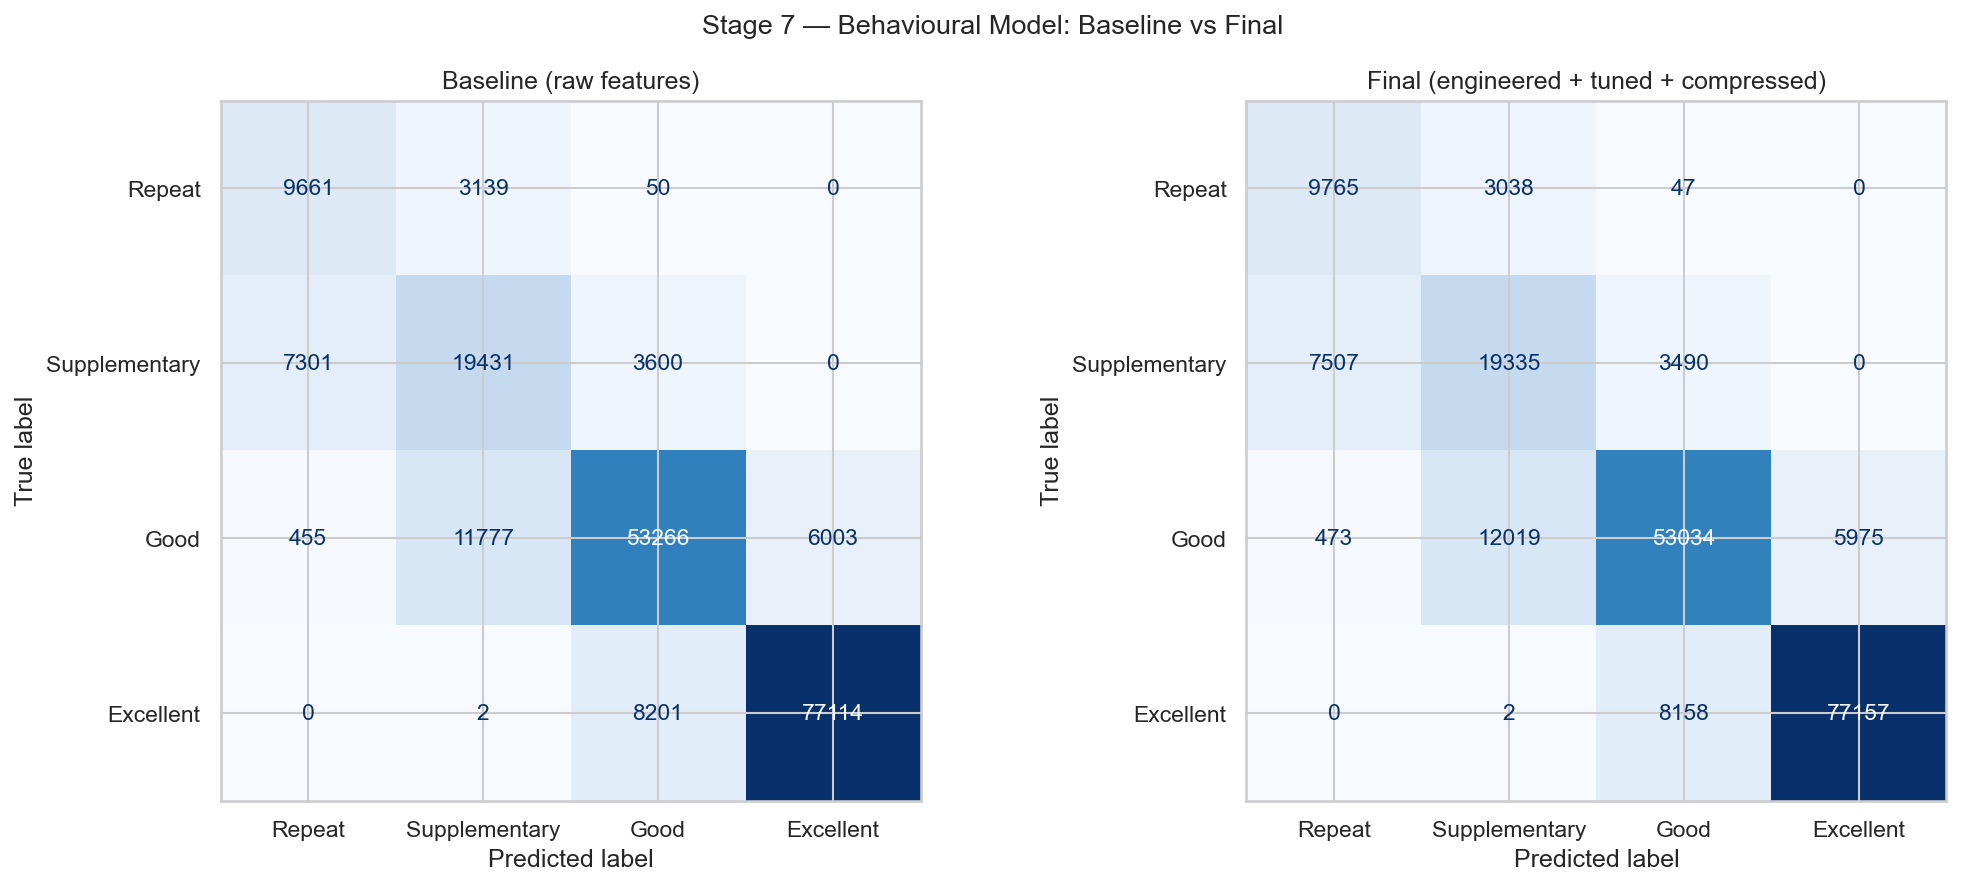

Saved: 03b_confusion_behav_comparison.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds, title, fname in [
    (axes[0], y_pred_base,        'Baseline (raw features)',       ''),
    (axes[1], y_pred_final_behav, 'Final (engineered + tuned + compressed)', ''),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, preds),
        display_labels=BAND_ORDER
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)

plt.suptitle('Stage 7 — Behavioural Model: Baseline vs Final', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}03b_confusion_behav_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: 03b_confusion_behav_comparison.png')

In [19]:
# ── Summary table of all model versions ────────────────────────────────
summary = pd.DataFrame([
    {'Model': 'Baseline (raw features)',           'F1 macro': round(f1_base,  4), 'Notes': 'No engineering, no tuning'},
    {'Model': 'Engineered features',               'F1 macro': round(f1_eng,   4), 'Notes': '+study_x_attendance, distraction_ratio, risk_score'},
    {'Model': 'Tuned (GridSearchCV)',               'F1 macro': round(f1_tuned, 4), 'Notes': f'Best params: {best_params}'},
    {'Model': f'Final compressed ({BEST_N_TREES} trees)', 'F1 macro': round(f1_final, 4), 'Notes': f'{size_final:.0f} KB — app-ready'},
])
print('=== Behavioural Model Progression ===')
display(summary)
summary.to_csv(f'{REPORT_DIR}07_model_progression.csv', index=False)
print('Saved: 07_model_progression.csv')

=== Behavioural Model Progression ===


,Model,F1 macro,Notes
0,Baseline (raw features),0.7337,"No engineering, no tuning"
1,Engineered features,0.7338,"+study_x_attendance, distraction_ratio, risk_s..."
2,Tuned (GridSearchCV),0.7327,"Best params: {'max_depth': 10, 'max_features':..."
3,Final compressed (25 trees),0.7326,4325 KB — app-ready


Saved: 07_model_progression.csv


## Stage 8 — Visualise Band Distributions

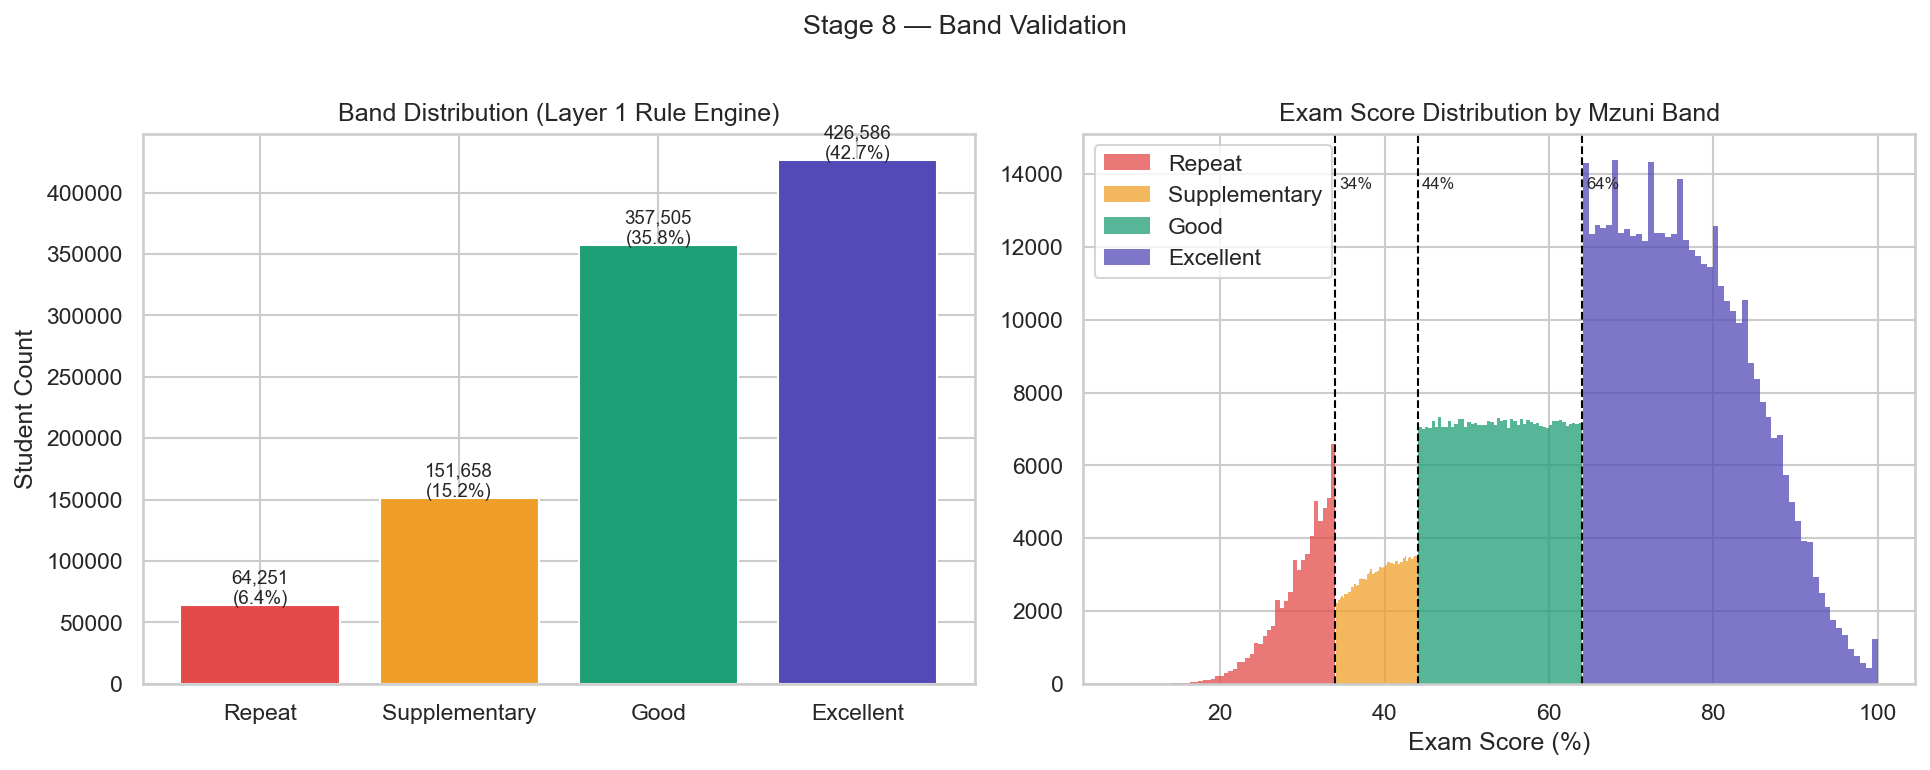

Saved: 04_band_distribution.png


In [20]:
band_counts = df['mzuni_band'].value_counts().reindex(BAND_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(BAND_ORDER, band_counts.values,
            color=[PALETTE[b] for b in BAND_ORDER], edgecolor='white')
axes[0].set_title('Band Distribution (Layer 1 Rule Engine)')
axes[0].set_ylabel('Student Count')
for i, v in enumerate(band_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)

for band in BAND_ORDER:
    subset = df[df['mzuni_band'] == band]['exam_score']
    axes[1].hist(subset, bins=50, alpha=0.75, label=band,
                 color=PALETTE[band], edgecolor='none')
for thresh, lbl in [(34, '34%'), (44, '44%'), (64, '64%')]:
    axes[1].axvline(thresh, color='black', linestyle='--', linewidth=1)
    axes[1].text(thresh + 0.5, axes[1].get_ylim()[1] * 0.9, lbl, fontsize=8)
axes[1].set_title('Exam Score Distribution by Mzuni Band')
axes[1].set_xlabel('Exam Score (%)')
axes[1].legend()

plt.suptitle('Stage 8 — Band Validation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}04_band_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: 04_band_distribution.png')

=== Band Feature Profiles ===


,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,study_x_attendance,distraction_ratio,risk_score,exam_score,count,% of total
mzuni_band,,,,,,,,,,
Repeat,1.53,72.93,6.5,3.5,1.11,2.28,0.55,29.76,64251,6.4
Supplementary,2.11,78.37,6.5,3.5,1.62,1.74,0.50,39.40,151658,15.2
Good,3.76,79.96,6.5,3.5,2.96,0.99,0.41,54.06,357505,35.8
Excellent,6.41,81.69,6.5,3.5,5.21,0.55,0.27,76.80,426586,42.7


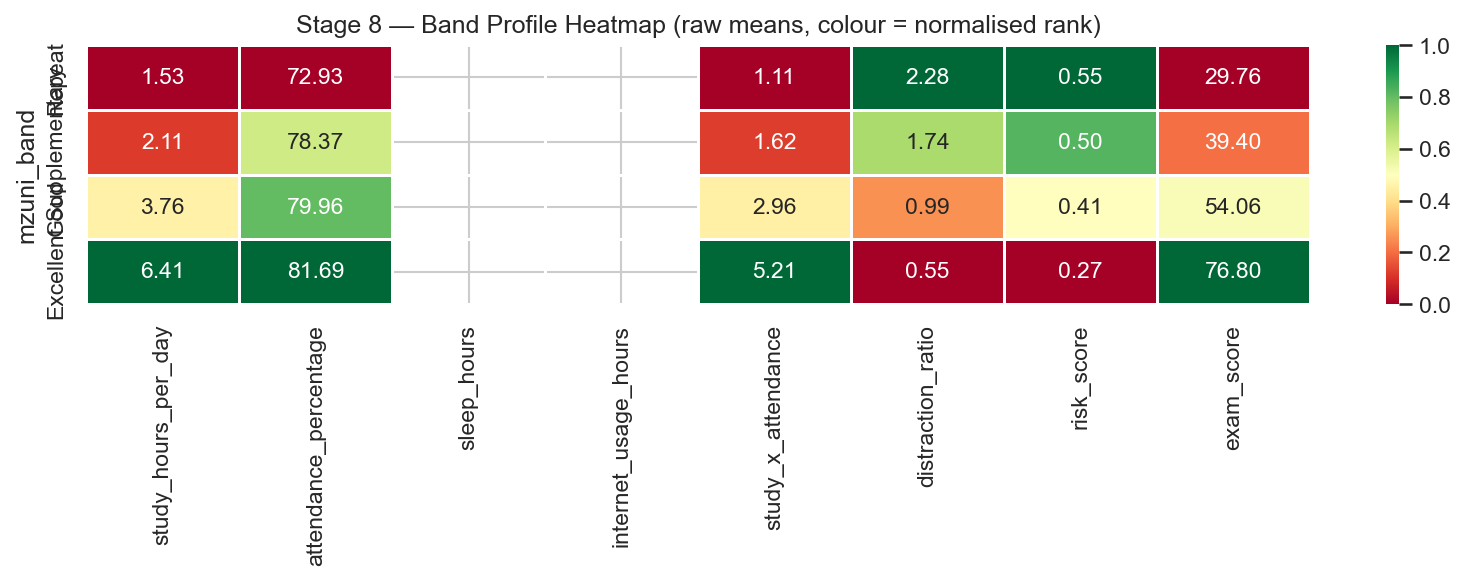

Saved: 04b_band_heatmap.png


In [21]:
profile = df.groupby('mzuni_band')[ALL_FEATURES].mean().round(2).reindex(BAND_ORDER)
profile['count']      = df['mzuni_band'].value_counts().reindex(BAND_ORDER)
profile['% of total'] = (profile['count'] / len(df) * 100).round(1)
print('=== Band Feature Profiles ===')
display(profile)
profile.to_csv(f'{REPORT_DIR}04_band_profiles.csv')

profile_norm = (profile[ALL_FEATURES] - profile[ALL_FEATURES].min()) / \
               (profile[ALL_FEATURES].max() - profile[ALL_FEATURES].min())
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(profile_norm, annot=profile[ALL_FEATURES],
            fmt='.2f', cmap='RdYlGn', linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Stage 8 — Band Profile Heatmap (raw means, colour = normalised rank)')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}04b_band_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 04b_band_heatmap.png')

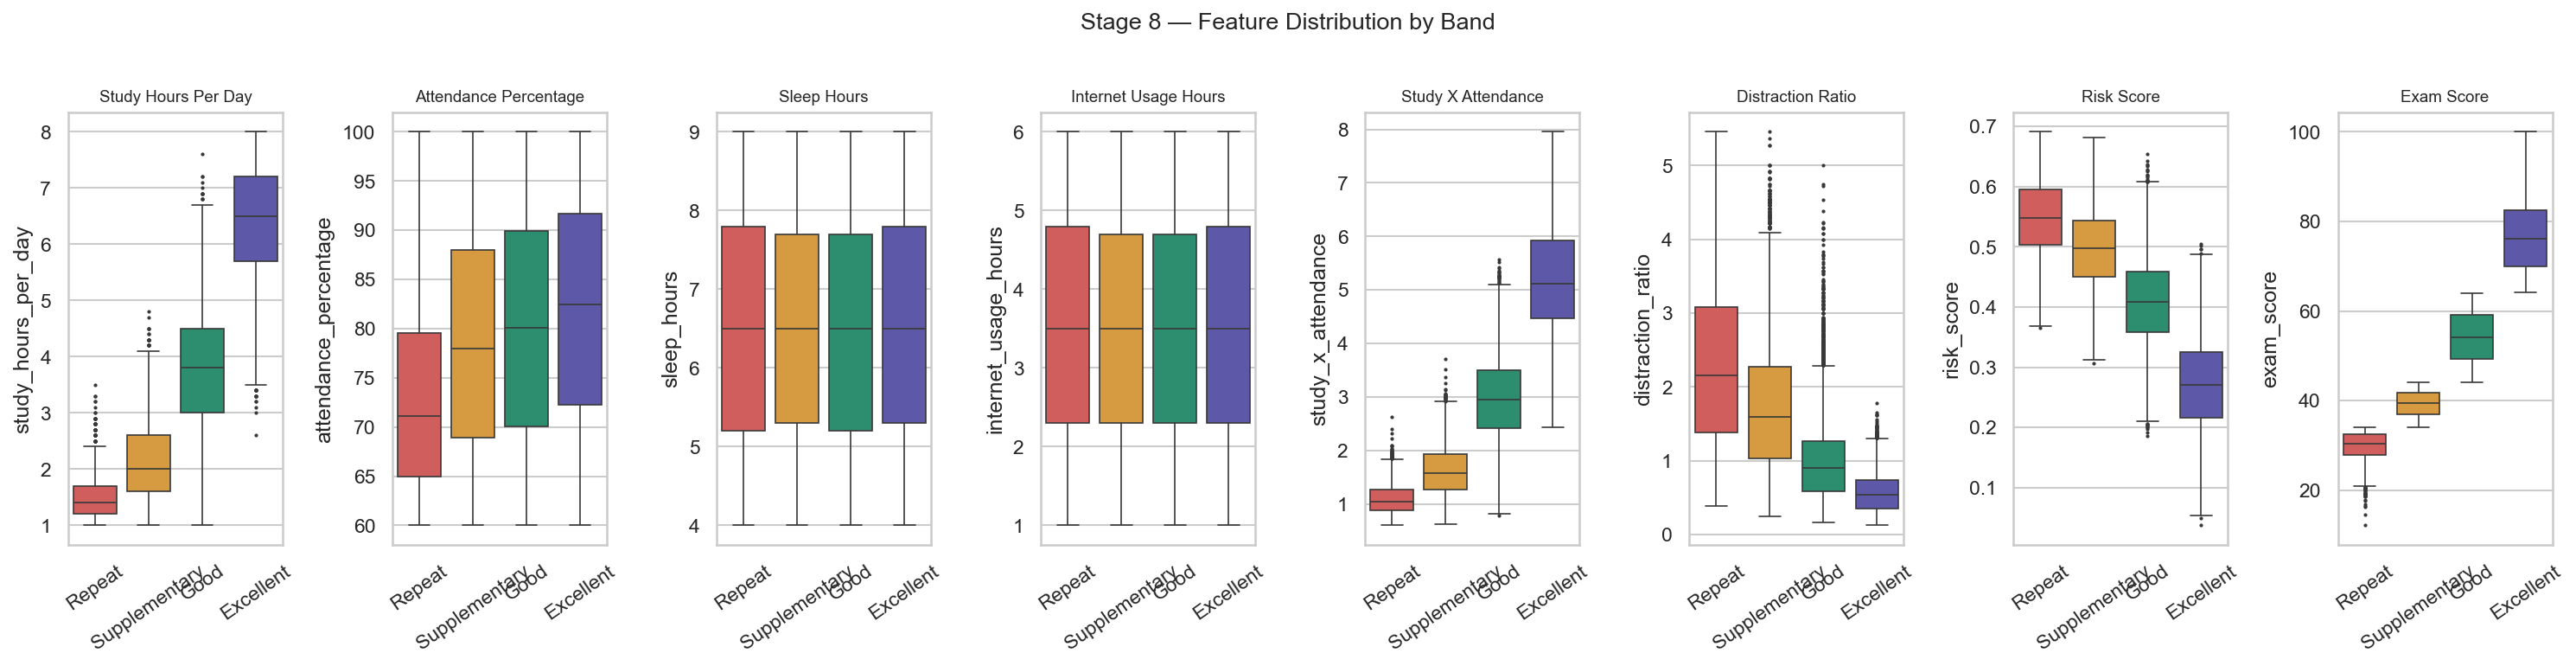

Saved: 04c_boxplots.png


In [22]:
fig, axes = plt.subplots(1, len(ALL_FEATURES), figsize=(20, 5))
for ax, col in zip(axes, ALL_FEATURES):
    sns.boxplot(data=df.sample(30_000, random_state=2),
                x='mzuni_band', y=col, order=BAND_ORDER,
                palette=PALETTE, ax=ax, linewidth=0.8, fliersize=1)
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
plt.suptitle('Stage 8 — Feature Distribution by Band', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}04c_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved: 04c_boxplots.png')

## Stage 9 — SHAP Explainability

SHAP explains both the full model and the behavioural model directly.
Side-by-side plots show which features matter for post-CA prediction
vs early warning — this is the 'Explainability Report' deliverable from the proposal.

In [23]:
shap_sample_all  = X_all_te.sample(3000, random_state=42)
shap_sample_beh  = X_beh_te.loc[shap_sample_all.index]

explainer_full  = shap.TreeExplainer(rf_full)
explainer_behav = shap.TreeExplainer(rf_behav_final)

sv_full  = np.array(explainer_full.shap_values(shap_sample_all))
sv_behav = np.array(explainer_behav.shap_values(shap_sample_beh))

def normalise_shap(sv, n):
    """Ensure shape is (n_samples, n_features, n_classes)."""
    if sv.ndim == 3 and sv.shape[0] == n: return sv
    if sv.ndim == 3 and sv.shape[0] == 4: return sv.transpose(1, 2, 0)
    raise ValueError(f'Unexpected SHAP shape: {sv.shape}')

sv_full_3d  = normalise_shap(sv_full,  len(shap_sample_all))
sv_behav_3d = normalise_shap(sv_behav, len(shap_sample_beh))

print(f'Full model SHAP  : {sv_full_3d.shape}')
print(f'Behav model SHAP : {sv_behav_3d.shape}')

Full model SHAP  : (3000, 8, 4)
Behav model SHAP : (3000, 7, 4)


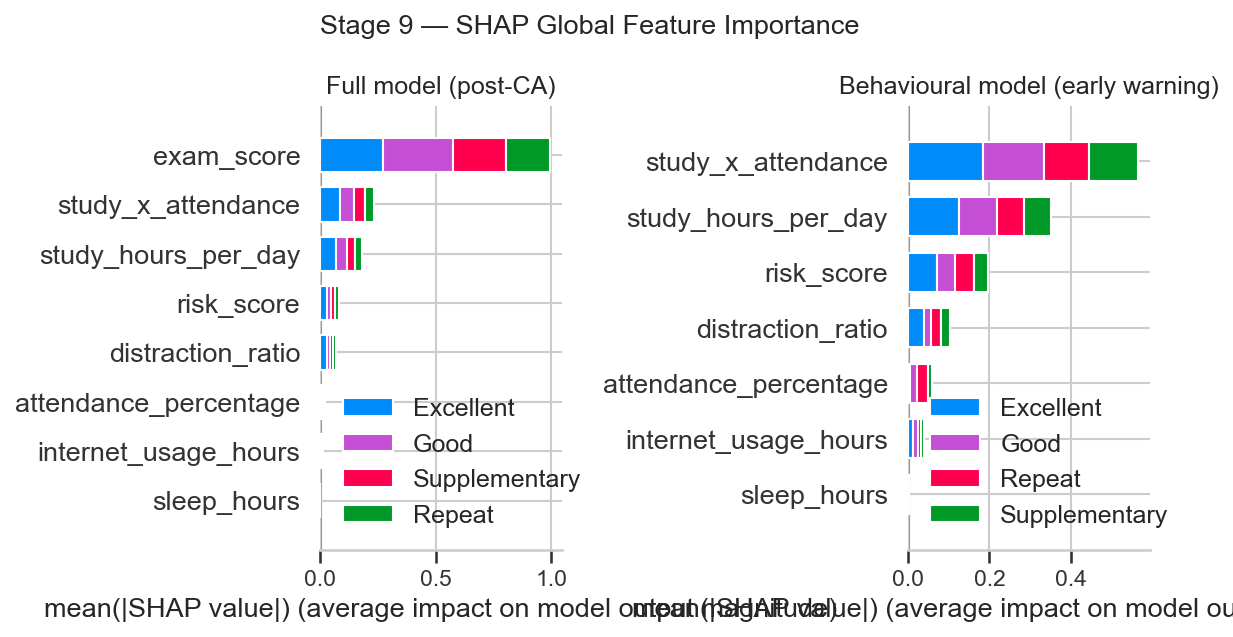

Saved: 05a_shap_global.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
shap.summary_plot(sv_full_3d, shap_sample_all,
                  class_names=BAND_ORDER, plot_type='bar', show=False)
axes[0].set_title('Full model (post-CA)')

plt.sca(axes[1])
shap.summary_plot(sv_behav_3d, shap_sample_beh,
                  class_names=BAND_ORDER, plot_type='bar', show=False)
axes[1].set_title('Behavioural model (early warning)')

plt.suptitle('Stage 9 — SHAP Global Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}05a_shap_global.png', bbox_inches='tight')
plt.show()
print('Saved: 05a_shap_global.png')

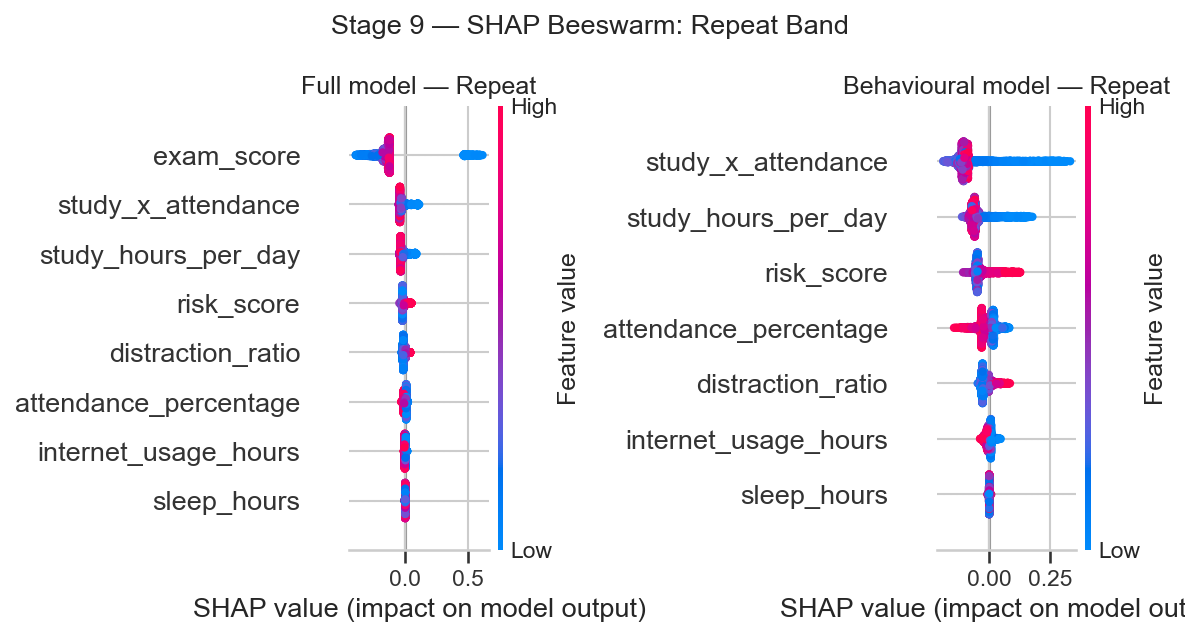

Saved: 05b_shap_repeat.png


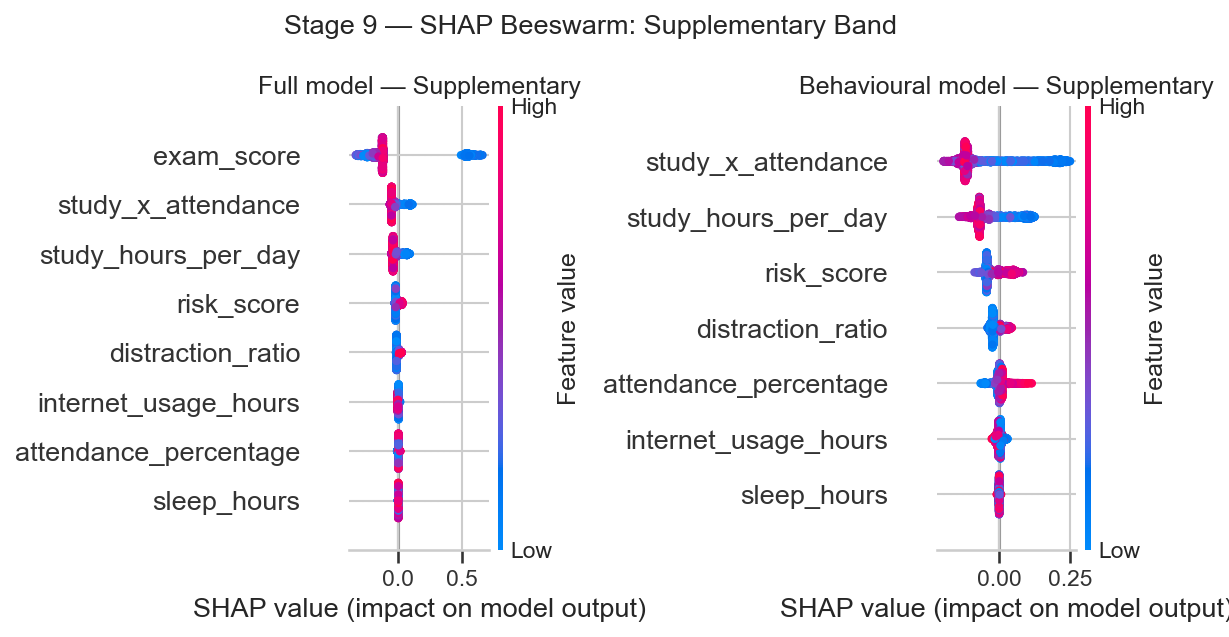

Saved: 05c_shap_supplementary.png


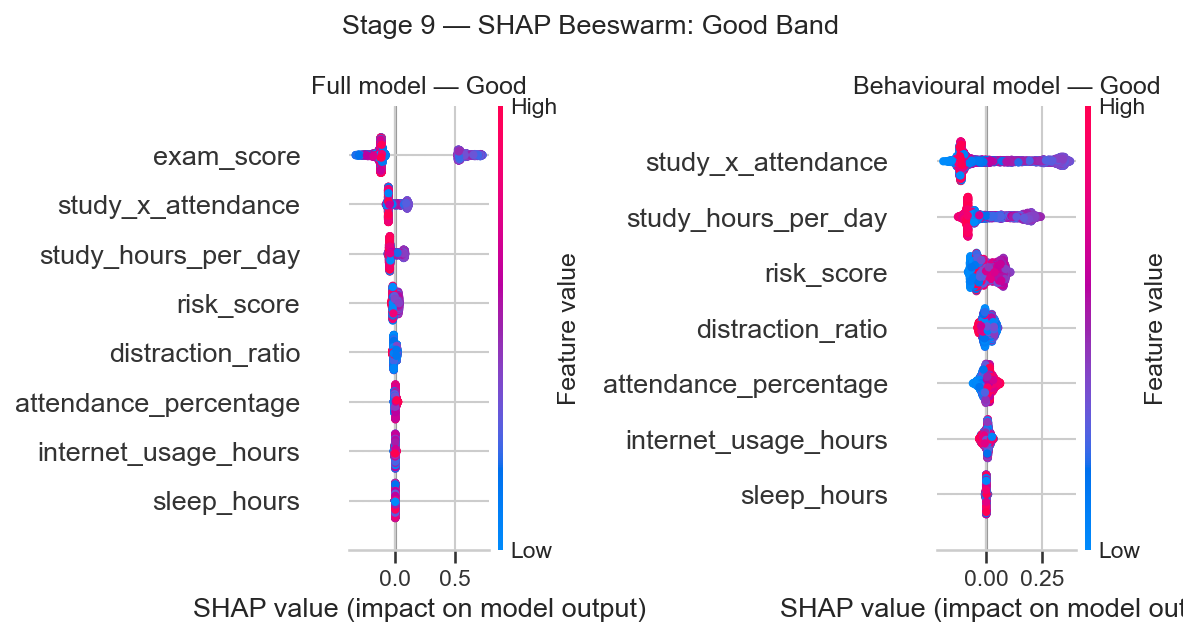

Saved: 05d_shap_good.png


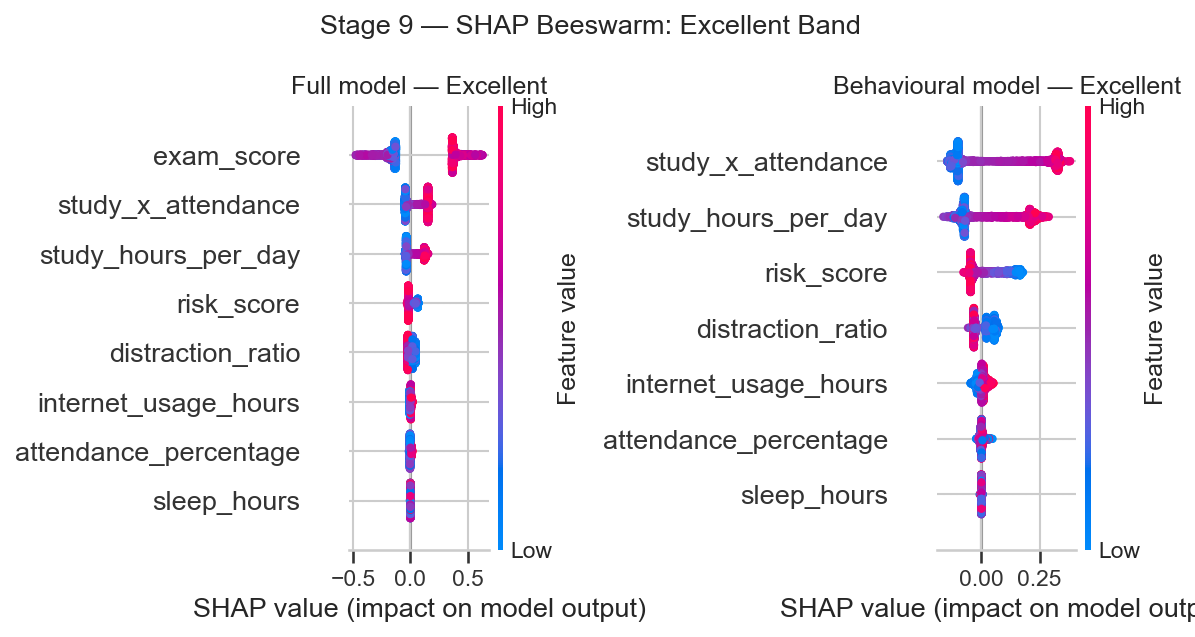

Saved: 05e_shap_excellent.png


In [25]:
for class_idx, band_name in enumerate(BAND_ORDER):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    plt.sca(axes[0])
    shap.summary_plot(sv_full_3d[:, :, class_idx],  shap_sample_all, show=False)
    axes[0].set_title(f'Full model — {band_name}')

    plt.sca(axes[1])
    shap.summary_plot(sv_behav_3d[:, :, class_idx], shap_sample_beh, show=False)
    axes[1].set_title(f'Behavioural model — {band_name}')

    plt.suptitle(f'Stage 9 — SHAP Beeswarm: {band_name} Band', fontsize=13)
    plt.tight_layout()
    fname = f'05{chr(98+class_idx)}_shap_{band_name.lower()}.png'
    plt.savefig(f'{REPORT_DIR}{fname}', bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

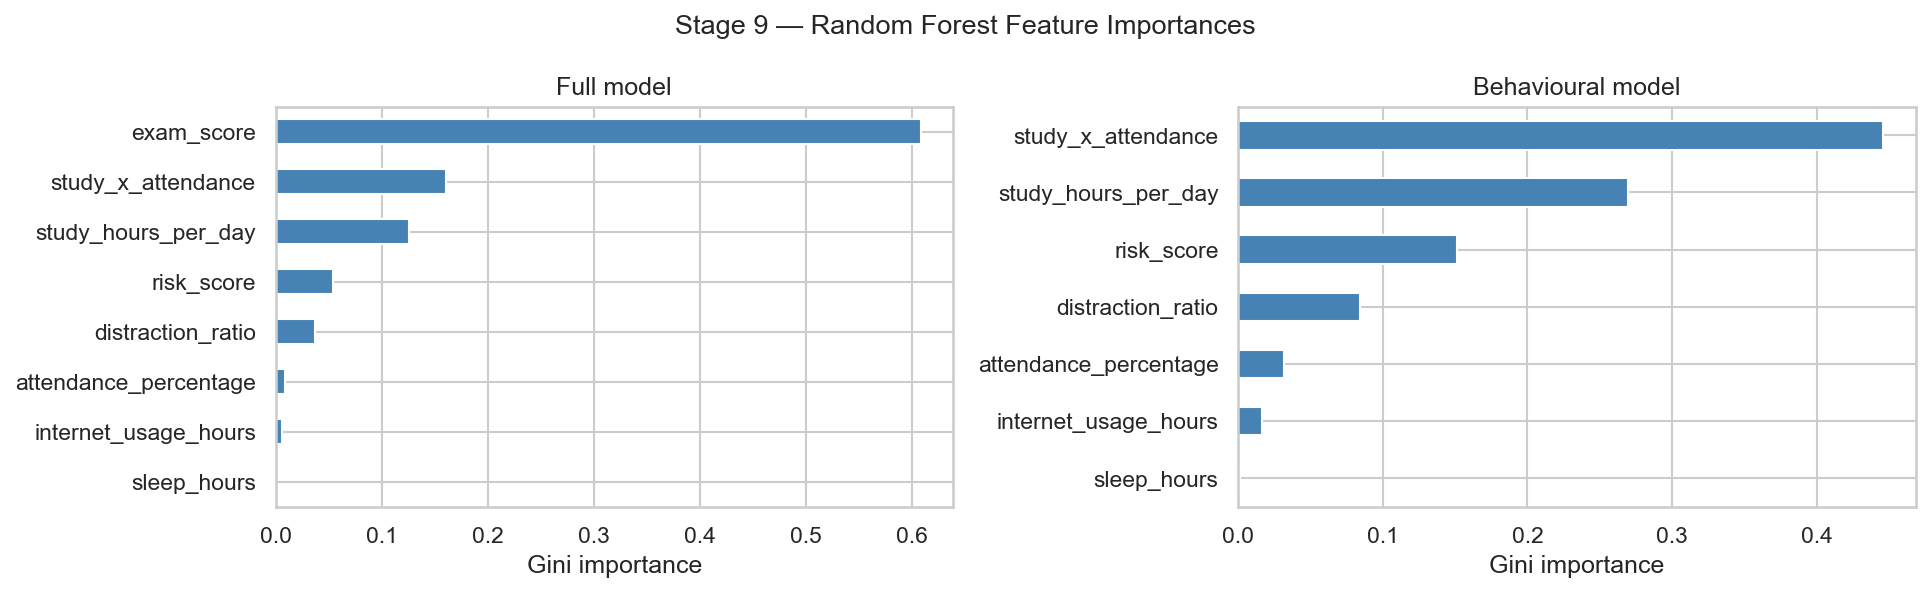

Saved: 05f_rf_importances.png

Full model importances:
exam_score               0.6077
study_x_attendance       0.1604
study_hours_per_day      0.1255
risk_score               0.0537
distraction_ratio        0.0373
attendance_percentage    0.0092
internet_usage_hours     0.0057
sleep_hours              0.0005

Behavioural model importances:
study_x_attendance       0.4460
study_hours_per_day      0.2694
risk_score               0.1512
distraction_ratio        0.0840
attendance_percentage    0.0319
internet_usage_hours     0.0162
sleep_hours              0.0012


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, model, feats, title in [
    (axes[0], rf_full,         ALL_FEATURES,   'Full model'),
    (axes[1], rf_behav_final,  BEHAV_FEATURES, 'Behavioural model'),
]:
    imp = pd.Series(model.feature_importances_, index=feats).sort_values()
    imp.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Gini importance')

plt.suptitle('Stage 9 — Random Forest Feature Importances', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}05f_rf_importances.png', bbox_inches='tight')
plt.show()
print('Saved: 05f_rf_importances.png')

print('\nFull model importances:')
print(pd.Series(rf_full.feature_importances_, index=ALL_FEATURES)
      .sort_values(ascending=False).round(4).to_string())
print('\nBehavioural model importances:')
print(pd.Series(rf_behav_final.feature_importances_, index=BEHAV_FEATURES)
      .sort_values(ascending=False).round(4).to_string())

## Stage 10 — Prediction Engine & End-to-End Test

The `predict_student()` function is what the application will call.
It combines both layers and produces a complete recommendation output.

In [27]:
RECOMMENDATIONS = {
    'Repeat': {
        'student': [
            'Seek academic counselling immediately — do not wait until exams.',
            'Increase study hours to at least 4 hours per day.',
            'Attend every class — missing even one session compounds the risk.',
            'Reduce recreational internet usage to under 1 hour on study days.',
            'Form a study group with Good or Excellent band peers.',
        ],
        'lecturer': [
            'Flag for urgent one-on-one academic review.',
            'Escalate to the academic advisor or HOD immediately.',
            'Provide additional practice questions targeted at foundational concepts.',
            'Schedule a mid-semester progress check-in.',
        ],
    },
    'Supplementary': {
        'student': [
            'You are close to the pass boundary — focused effort now can shift your outcome.',
            'Target the specific CA components where marks were lost.',
            'Attend all remaining classes and tutorials without exception.',
            'Reduce internet usage on study days.',
            'Use office hours to get feedback on weak areas.',
        ],
        'lecturer': [
            'Provide supplementary practice materials and past questions.',
            'Schedule an office hours check-in for this student.',
            'Monitor attendance closely over the next two weeks.',
        ],
    },
    'Good': {
        'student': [
            'You are on track — maintain your current study routine.',
            'Push for consistency: aim to add 30 minutes of study per day.',
            'Attempt past exam papers under timed conditions.',
            'Set a stretch target of the Excellent band for the final exam.',
        ],
        'lecturer': [
            'Encourage with extension tasks or challenge questions.',
            'Suggest peer tutoring to reinforce and deepen knowledge.',
        ],
    },
    'Excellent': {
        'student': [
            'Outstanding — maintain your current habits.',
            'Consider mentoring peers in lower bands.',
            'Explore supplementary reading to prepare for advanced coursework.',
        ],
        'lecturer': [
            'Recognise this performance publicly where appropriate.',
            'Assign a peer mentorship role to extend impact across the cohort.',
        ],
    },
}

def add_engineered_features(data: dict) -> dict:
    """Compute engineered features from raw inputs. Used at inference time."""
    d = data.copy()
    d['study_x_attendance'] = d['study_hours_per_day'] * d['attendance_percentage'] / 100
    d['distraction_ratio']  = min(d['internet_usage_hours'] / (d['study_hours_per_day'] + 0.1), 10)
    study_norm   = d['study_hours_per_day']   / df['study_hours_per_day'].max()
    attend_norm  = d['attendance_percentage']  / 100
    internet_norm= d['internet_usage_hours']   / df['internet_usage_hours'].max()
    d['risk_score'] = (1 - study_norm)*0.4 + (1 - attend_norm)*0.4 + internet_norm*0.2
    return d

def predict_student(raw_data: dict, mode: str = 'full') -> dict:
    """
    Two-layer prediction for a single student.

    Parameters
    ----------
    raw_data : dict with keys:
        Always required: study_hours_per_day, attendance_percentage,
                         sleep_hours, internet_usage_hours
        Full mode only : exam_score

    mode : 'full'  — post-CA prediction (requires exam_score)
           'early' — mid-semester early warning (no exam_score needed)

    Returns
    -------
    dict with band, confidence, probabilities, top_drivers, recommendations
    """
    data = add_engineered_features(raw_data)

    if mode == 'full':
        if 'exam_score' not in data:
            raise ValueError('Full mode requires exam_score.')
        band   = assign_mzuni_band(data['exam_score'])   # Layer 1
        model  = rf_full
        feats  = ALL_FEATURES
    else:
        band   = None   # unknown until exam
        model  = rf_behav_final
        feats  = BEHAV_FEATURES

    input_df   = pd.DataFrame([data])[feats]
    proba      = model.predict_proba(input_df)[0]
    pred_int   = model.predict(input_df)[0]
    pred_band  = INT_TO_BAND[pred_int]
    final_band = band if mode == 'full' else pred_band
    confidence = proba[BAND_TO_INT[final_band]] * 100

    # SHAP drivers
    exp    = shap.TreeExplainer(model)
    sv     = normalise_shap(np.array(exp.shap_values(input_df)), 1)
    sv_cls = sv[0, :, BAND_TO_INT[final_band]]
    drivers= pd.Series(np.abs(sv_cls), index=feats).sort_values(ascending=False)

    return {
        'mode':             mode,
        'band':             final_band,
        'ml_prediction':    pred_band,
        'confidence':       round(confidence, 1),
        'probabilities':    {b: round(proba[i]*100, 1) for i, b in enumerate(BAND_ORDER)},
        'top_drivers':      drivers.head(3).index.tolist(),
        'driver_values':    drivers.head(3).round(4).to_dict(),
        'student_actions':  RECOMMENDATIONS[final_band]['student'],
        'lecturer_actions': RECOMMENDATIONS[final_band]['lecturer'],
    }

print('predict_student() ready.')

predict_student() ready.


In [28]:
# ── Test: one student per band + one early warning ───────────────────────
test_students = [
    {'name': 'Alice — Repeat (full)',
     'mode': 'full',
     'data': {'study_hours_per_day':1.5,'attendance_percentage':42.0,
               'sleep_hours':5.0,'internet_usage_hours':7.0,'exam_score':22.0}},
    {'name': 'Bob — Supplementary (full)',
     'mode': 'full',
     'data': {'study_hours_per_day':2.5,'attendance_percentage':61.0,
               'sleep_hours':6.5,'internet_usage_hours':4.0,'exam_score':40.0}},
    {'name': 'Carol — Good (full)',
     'mode': 'full',
     'data': {'study_hours_per_day':4.0,'attendance_percentage':78.0,
               'sleep_hours':7.0,'internet_usage_hours':2.5,'exam_score':57.0}},
    {'name': 'David — Excellent (full)',
     'mode': 'full',
     'data': {'study_hours_per_day':6.5,'attendance_percentage':95.0,
               'sleep_hours':8.0,'internet_usage_hours':1.0,'exam_score':82.0}},
    {'name': 'Eve — Early warning (no exam score yet)',
     'mode': 'early',
     'data': {'study_hours_per_day':1.2,'attendance_percentage':38.0,
               'sleep_hours':5.0,'internet_usage_hours':8.0}},
]

for s in test_students:
    r = predict_student(s['data'], mode=s['mode'])
    print('=' * 64)
    print(f"Student  : {s['name']}")
    print(f"Mode     : {r['mode']}")
    print(f"Band     : {r['band']}  (ML predicted: {r['ml_prediction']})")
    print(f"Confidence    : {r['confidence']}%")
    print(f"Probabilities : {r['probabilities']}")
    print(f"Top drivers   : {r['top_drivers']}")
    print(f"Student action: {r['student_actions'][0]}")
    print(f"Lecturer action: {r['lecturer_actions'][0]}")
print('=' * 64)

Student  : Alice — Repeat (full)
Mode     : full
Band     : Repeat  (ML predicted: Repeat)
Confidence    : 99.5%
Probabilities : {'Repeat': 99.5, 'Supplementary': 0.5, 'Good': 0.0, 'Excellent': 0.0}
Top drivers   : ['exam_score', 'study_x_attendance', 'study_hours_per_day']
Student action: Seek academic counselling immediately — do not wait until exams.
Lecturer action: Flag for urgent one-on-one academic review.
Student  : Bob — Supplementary (full)
Mode     : full
Band     : Supplementary  (ML predicted: Supplementary)
Confidence    : 98.7%
Probabilities : {'Repeat': 0.7, 'Supplementary': 98.7, 'Good': 0.6, 'Excellent': 0.0}
Top drivers   : ['exam_score', 'study_x_attendance', 'study_hours_per_day']
Student action: You are close to the pass boundary — focused effort now can shift your outcome.
Lecturer action: Provide supplementary practice materials and past questions.
Student  : Carol — Good (full)
Mode     : full
Band     : Good  (ML predicted: Good)
Confidence    : 99.6%
Probabil

In [29]:
# ── Batch test: 2000 held-out students ──────────────────────────────────
print('Running batch test on 2,000 held-out students...')
results = []
for _, row in X_all_te.sample(2000, random_state=99).iterrows():
    raw = {f: row[f] for f in RAW_BEHAV + ['exam_score']}
    r   = predict_student(raw, mode='full')
    results.append({
        'true':      INT_TO_BAND[y_test.loc[row.name]],
        'predicted': r['band'],
        'confidence':r['confidence']
    })

res_df   = pd.DataFrame(results)
accuracy = (res_df['true'] == res_df['predicted']).mean()

print(f'\nBatch accuracy : {accuracy*100:.1f}%')
print(f'Mean confidence: {res_df["confidence"].mean():.1f}%')
print(f'\nPer-band accuracy:')
for band in BAND_ORDER:
    sub = res_df[res_df['true'] == band]
    if len(sub):
        acc = (sub['true'] == sub['predicted']).mean()
        print(f'  {band:<15}: {acc*100:.1f}%  (n={len(sub)})')

res_df.to_csv(f'{REPORT_DIR}06_batch_test_results.csv', index=False)
print('\nSaved: 06_batch_test_results.csv')

Running batch test on 2,000 held-out students...

Batch accuracy : 100.0%
Mean confidence: 98.9%

Per-band accuracy:
  Repeat         : 100.0%  (n=129)
  Supplementary  : 100.0%  (n=306)
  Good           : 100.0%  (n=708)
  Excellent      : 100.0%  (n=857)

Saved: 06_batch_test_results.csv


## Stage 11 — Export All Report Assets

In [30]:
# Labelled dataset
df[['student_id','age','gender'] + ALL_FEATURES + ['mzuni_band']]\
  .to_csv(f'{REPORT_DIR}07_students_with_bands.csv', index=False)
print('Saved: 07_students_with_bands.csv')

# Intervention recommendations table
rows = []
ranges = {'Repeat':'0-34%','Supplementary':'35-44%','Good':'45-64%','Excellent':'65-100%'}
for band in BAND_ORDER:
    rows.append({
        'Band':             band,
        'Score range':      ranges[band],
        'Student actions':  ' | '.join(RECOMMENDATIONS[band]['student'][:3]),
        'Lecturer actions': ' | '.join(RECOMMENDATIONS[band]['lecturer'][:2]),
    })
int_df = pd.DataFrame(rows)
int_df.to_csv(f'{REPORT_DIR}08_intervention_recommendations.csv', index=False)
display(int_df)
print('Saved: 08_intervention_recommendations.csv')

Saved: 07_students_with_bands.csv


,Band,Score range,Student actions,Lecturer actions
0,Repeat,0-34%,Seek academic counselling immediately — do not...,Flag for urgent one-on-one academic review. | ...
1,Supplementary,35-44%,You are close to the pass boundary — focused e...,Provide supplementary practice materials and p...
2,Good,45-64%,You are on track — maintain your current study...,Encourage with extension tasks or challenge qu...
3,Excellent,65-100%,Outstanding — maintain your current habits. | ...,Recognise this performance publicly where appr...


Saved: 08_intervention_recommendations.csv


In [32]:
# Final model file sizes
print('=== app_model/ contents ===')
for fname in sorted(os.listdir(MODEL_DIR)):
    kb = os.path.getsize(f'{MODEL_DIR}{fname}') / 1024
    print(f'  {fname:<40} {kb:>8.0f} KB  ({kb/1024:.1f} MB)')

=== app_model/ contents ===
  all_feature_names.pkl                           0 KB  (0.0 MB)
  band_order.pkl                                  0 KB  (0.0 MB)
  band_to_int.pkl                                 0 KB  (0.0 MB)
  behav_feature_names.pkl                         0 KB  (0.0 MB)
  int_to_band.pkl                                 0 KB  (0.0 MB)
  rf_behav_model.pkl                           4325 KB  (4.2 MB)
  rf_full_model.pkl                           39319 KB  (38.4 MB)
  rule_engine.pkl                                 0 KB  (0.0 MB)
  scaler_behav.pkl                                1 KB  (0.0 MB)
  scaler_full.pkl                                 1 KB  (0.0 MB)


In [33]:
print('=' * 68)
print('PIPELINE COMPLETE — BSDS0322 (Improved Two-Layer Architecture)')
print('=' * 68)
print(f'Dataset          : {len(df):,} records')
print(f'Behavioural feats: {BEHAV_FEATURES}')
print(f'Full feats       : {ALL_FEATURES}')
print()
print('Model performance:')
print(f'  Full model CV F1 (macro)              : {cv_full.mean():.4f}')
print(f'  Behav baseline F1 (macro)             : {f1_base:.4f}')
print(f'  Behav final F1 (macro, compressed)    : {f1_final:.4f}')
print(f'  Total improvement (behav)             : +{(f1_final-f1_base)*100:.2f}%')
print()
print('Band distribution (Layer 1):')
for band in BAND_ORDER:
    n  = (df['mzuni_band'] == band).sum()
    ms = df[df['mzuni_band']==band]['exam_score'].mean()
    print(f'  {band:<15}: {n:>8,} ({n/len(df)*100:.1f}%)  mean score={ms:.1f}%')
print()
print('Report assets: ', sorted(os.listdir(REPORT_DIR)))
print('Model files  : ', sorted(os.listdir(MODEL_DIR)))
print('=' * 68)
print('Ready to build the application.')

PIPELINE COMPLETE — BSDS0322 (Improved Two-Layer Architecture)
Dataset          : 1,000,000 records
Behavioural feats: ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'study_x_attendance', 'distraction_ratio', 'risk_score']
Full feats       : ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'study_x_attendance', 'distraction_ratio', 'risk_score', 'exam_score']

Model performance:
  Full model CV F1 (macro)              : 1.0000
  Behav baseline F1 (macro)             : 0.7337
  Behav final F1 (macro, compressed)    : 0.7326
  Total improvement (behav)             : +-0.10%

Band distribution (Layer 1):
  Repeat         :   64,251 (6.4%)  mean score=29.8%
  Supplementary  :  151,658 (15.2%)  mean score=39.4%
  Good           :  357,505 (35.8%)  mean score=54.1%
  Excellent      :  426,586 (42.7%)  mean score=76.8%

Report assets:  ['01_distributions.png', '02_correlation_heatmap.png', '03a_confusion_full.png'

## Report Writing Guide

| File | Report Section |
|------|----------------|
| `01_distributions.png` | 5.1 Data Collection & EDA |
| `02_correlation_heatmap.png` | 5.2 Feature Engineering |
| `03a_confusion_full.png` | 5.4 Full model evaluation |
| `03b_confusion_behav_comparison.png` | 5.4 Behavioural model improvement |
| `04_band_distribution.png` | 5.3 Layer 1 — Rule Engine |
| `04b_band_heatmap.png` | 5.3 Band Profiles |
| `04c_boxplots.png` | 5.3 Feature Analysis |
| `05a_shap_global.png` | 5.3 SHAP — Global Importance |
| `05b–05e shap PNGs` | 5.3 SHAP — Per-band drivers |
| `05f_rf_importances.png` | 5.3 Feature Importances (Gini) |
| `06_batch_test_results.csv` | 5.4 Generalisation test |
| `07_model_progression.csv` | 5.4 Tuning summary table |
| `08_intervention_recommendations.csv` | Section 6 Expected Outcomes |
| `app_model/` folder | Appendix — deployment artefacts |